<a href="https://colab.research.google.com/github/pratheekshashetty-blip/machinelearningprojects/blob/main/forest_cover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


This dataset contains tree observations from four areas of the Roosevelt National Forest in Colorado. All observations are cartographic variables (no remote sensing) from 30 meter x 30 meter sections of forest. There are over half a million measurements total!

In [ ]:
Dataset:  https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset

In [ ]:

import numpy as np
import pandas as pd
import sklearn as skl
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%matplotlib inline

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')


Load Data

In [ ]:
data = pd.read_csv('/content/covtype.csv')

Inspection

In [ ]:
print("Shape of the dataset: ", data.shape)

Shape of the dataset:  (581012, 55)


In [ ]:
print("\nMissing values:", data.isnull().sum().sum())
print("\nDuplicate rows:", data.duplicated().sum())



Missing values: 0

Duplicate rows: 0


In [ ]:
print("First 5 rows: ")
data.head()


First 5 rows: 


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [ ]:

print("Last 5 rows: ")
data.tail()

Last 5 rows: 


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
581007,2396,153,20,85,17,108,240,237,118,837,...,0,0,0,0,0,0,0,0,0,3
581008,2391,152,19,67,12,95,240,237,119,845,...,0,0,0,0,0,0,0,0,0,3
581009,2386,159,17,60,7,90,236,241,130,854,...,0,0,0,0,0,0,0,0,0,3
581010,2384,170,15,60,5,90,230,245,143,864,...,0,0,0,0,0,0,0,0,0,3
581011,2383,165,13,60,4,67,231,244,141,875,...,0,0,0,0,0,0,0,0,0,3


Data Reconnaisence

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [ ]:
print("Missing Values in Data:", data.isnull().sum().sum())
print("Duplicated Values in Data:", data.duplicated().sum())

Missing Values in Data: 0
Duplicated Values in Data: 0


In [ ]:
data.columns


Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1',
       'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
       'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34',
       'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38',
       'Soil_Type39', 'Soil_Type40

In [ ]:
data.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [ ]:
cols_to_describe = data.columns[:10].tolist() + ['Cover_Type']

print("\nNumerical Statistics (Continuous Features Only):")
display(data[cols_to_describe].describe().T)


Numerical Statistics (Continuous Features Only):


,count,mean,std,min,25%,50%,75%,max
Elevation,581012.0,2959.365301,279.984734,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.656807,111.913721,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.103704,7.488242,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.428217,212.549356,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.418855,58.295232,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.146611,1559.254870,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.146049,26.769889,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.318716,19.768697,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.528263,38.274529,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.291226,1324.195210,0.0,1024.0,1710.0,2550.0,7173.0


In [ ]:

cover_labels = {
    1:"Spruce/Fir",
    2:"LodgepolePine",
    3:"Ponderosa Pine",
    4:"Cottonwood/Willow",
    5:"Aspen",
    6:"Douglas-fir",
    7:"Krummholz"
}

# Create a new column with the descriptive names
data['Cover_Type_Name'] = data['Cover_Type'].map(cover_labels)

class_summary= (
    data["Cover_Type_Name"]
    .value_counts()
    .rename_axis("Cover_Type_Name")
    .reset_index(name="Count")
)
class_summary["Percentage"] =(class_summary["Count"]/len(data)*100).round(2)
display(class_summary)

,Cover_Type_Name,Count,Percentage
0,LodgepolePine,283301,48.76
1,Spruce/Fir,211840,36.46
2,Ponderosa Pine,35754,6.15
3,Krummholz,20510,3.53
4,Douglas-fir,17367,2.99
5,Aspen,9493,1.63
6,Cottonwood/Willow,2747,0.47


Exploratory Data Analysis

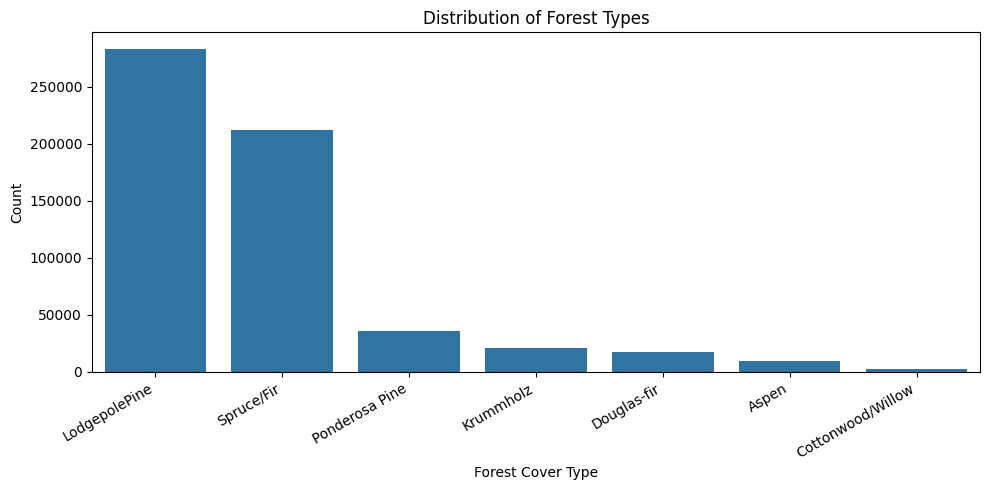

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=data,x='Cover_Type_Name', order= data["Cover_Type_Name"].value_counts().index)
plt.xticks(rotation=30, ha="right")
plt.xlabel("Forest Cover Type")
plt.ylabel("Count")
plt.title("Distribution of Forest Types")
plt.tight_layout()
plt.show()

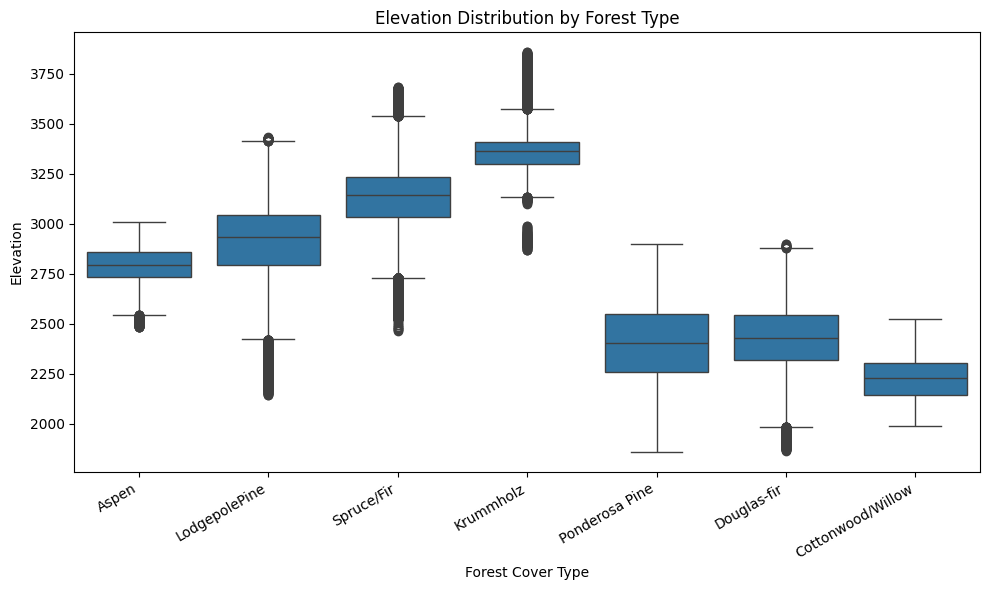

In [ ]:

plt.figure(figsize=(10,6))
sns.boxplot(data=data, x="Cover_Type_Name",y="Elevation")
plt.xticks(rotation=30, ha="right")
plt.xlabel("Forest Cover Type")
plt.ylabel("Elevation")
plt.title("Elevation Distribution by Forest Type")
plt.tight_layout()
plt.show()

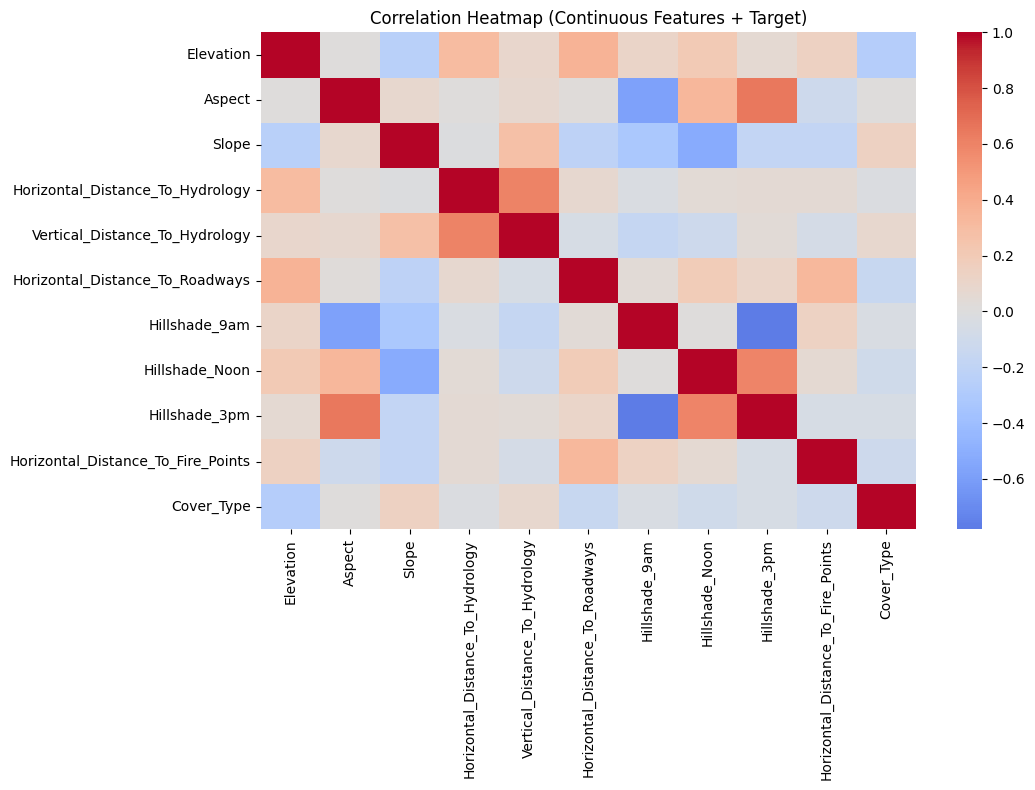

In [ ]:
continuous_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways", "Hillshade_9am", "Hillshade_Noon",
    "Hillshade_3pm", "Horizontal_Distance_To_Fire_Points"
]

plt.figure(figsize=(11, 8))
corr = data[continuous_features + ["Cover_Type"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Continuous Features + Target)")
plt.tight_layout()
plt.show()

Prepare features and target

In [ ]:
X= data.drop(columns=["Cover_Type","Cover_Type_Name"])
y= data["Cover_Type"].astype(int)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y)
print("Training Shape: ", X_train.shape)
print("Test Shape:", X_test.shape)

Training Shape:  (464809, 54)
Test Shape: (116203, 54)


Model training and Evaluation
by comparing Random Forest and XGBoost

In [ ]:
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    macro_f1 = f1_score(y_true, y_pred, average="macro")


    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"Accuracy     : {accuracy:.4f}")
    print(f"Weighted F1  : {weighted_f1:.4f}")
    print(f"Macro F1     : {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=[cover_labels[i] for i in sorted(cover_labels)]))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Weighted_F1": weighted_f1,
        "Macro_F1": macro_f1
    }



In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_results = evaluate_model("Random Forest", y_test, rf_preds)


Random Forest
-------------
Accuracy     : 0.9547
Weighted F1  : 0.9544
Macro F1     : 0.9250

Classification Report:
                   precision    recall  f1-score   support

       Spruce/Fir       0.97      0.94      0.95     42368
    LodgepolePine       0.95      0.97      0.96     56661
   Ponderosa Pine       0.94      0.96      0.95      7151
Cottonwood/Willow       0.91      0.85      0.88       549
            Aspen       0.95      0.78      0.86      1899
      Douglas-fir       0.93      0.89      0.91      3473
        Krummholz       0.97      0.95      0.96      4102

         accuracy                           0.95    116203
        macro avg       0.95      0.91      0.92    116203
     weighted avg       0.95      0.95      0.95    116203



In [ ]:
y_pred = model.predict(X_test)

In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train, (y_train - 1).astype(int))

# Make predictions on the test set
xgb_preds = xgb.predict(X_test)

# Convert y_test to 0-indexed for evaluation
y_test_0_indexed = (y_test - 1).astype(int)

# Evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('XGBoost Accuracy:', accuracy_score(y_test_0_indexed, xgb_preds))
print('Confusion Matrix:\n', confusion_matrix(y_test_0_indexed, xgb_preds))
print('Classification Report:\n', classification_report(y_test_0_indexed, xgb_preds))

In [ ]:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=7,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_xgb)
xgb_preds_zero_indexed = xgb_model.predict(X_test)
xgb_preds = xgb_preds_zero_indexed + 1

xgb_results = evaluate_model("XGBoost", y_test, xgb_preds)

**Model Comparisson:**

Random Forest 0.95

XGBoost: 0.87

For this dataseet Random Forest achived higher accuracy

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, preds))

Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cover_labels = {
1:"Spruce/Fir",
2:"LodgepolePine",
3:"Ponderosa Pine",
4:"Cottonwood/Willow",
5:"Aspen",
6:"Douglas-fir",
7:"Krummholz"
}
cm= confusion_matrix(y_test, preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=[cover_labels[i] for i in range(1,8)],
            yticklabels=[cover_labels[i] for i in range(1,8)])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Feature Importance

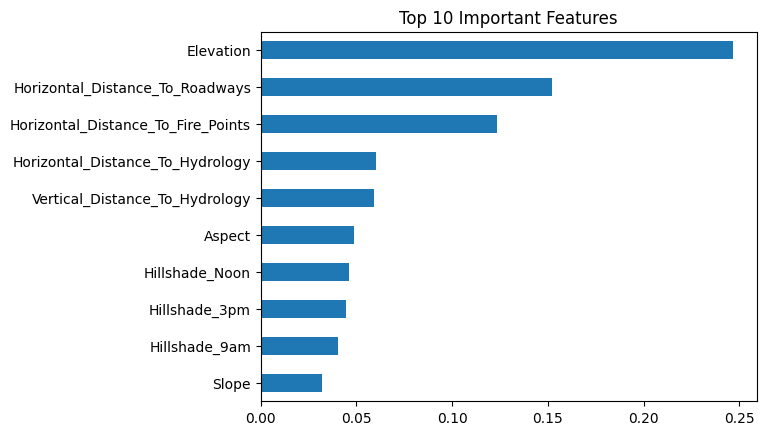

In [ ]:
importances = model.feature_importances_
features = X.columns

pd.Series(importances, index=features).sort_values().tail(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()

Sample Prediction

In [ ]:
sample_rows=data.sample(10,random_state=42).copy()

In [ ]:
sample_X = sample_rows.drop(columns=['Cover_Type', "Cover_Type_Name"])
sample_rows["Predicted_Cover_Type"] = rf_model.predict(sample_X)
sample_rows["Predicted_Cover_Type_Name"] = sample_rows["Predicted_Cover_Type"].map(cover_labels)

display(
    sample_rows[
        ["Cover_Type", "Cover_Type_Name", "Predicted_Cover_Type", "Predicted_Cover_Type_Name"]
    ]
)


,Cover_Type,Cover_Type_Name,Predicted_Cover_Type,Predicted_Cover_Type_Name
250728,1,Spruce/Fir,1,Spruce/Fir
246788,2,LodgepolePine,2,LodgepolePine
407714,2,LodgepolePine,2,LodgepolePine
25713,2,LodgepolePine,2,LodgepolePine
21820,2,LodgepolePine,2,LodgepolePine
251274,3,Ponderosa Pine,3,Ponderosa Pine
52354,2,LodgepolePine,2,LodgepolePine
246168,1,Spruce/Fir,1,Spruce/Fir
477113,2,LodgepolePine,2,LodgepolePine
78834,2,LodgepolePine,2,LodgepolePine
